<a href="https://colab.research.google.com/github/hgmhd7/AI-Machine-Learning/blob/main/Graph_Neural_Network_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNNs for Automated Feature Engineering

## Manual Feature Engineering

Feature engineering is a pivotal process in machine learning, *involving the selection, creation, and transformation of input variables* to enhance model performance. It entails tasks such as feature selection to identify essential variables, creating new features to capture complex relationships, and handling data preprocessing tasks like encoding categorical variables or scaling values. *This process heavily relies on domain expertise and evolves over time to adapt to changing data dynamics, ultimately ensuring that machine learning models are equipped with the most relevant and informative features for accurate predictions and insights.*

**In the Mini Project on Graph ML, we performed manual feature engineering on the Stanford Facebook Dataset for clustering Graph nodes**

## Automated Feature Engineering through Supervised Neural Networks

Neural networks excel not only in learning complex patterns but also in automating feature engineering. Rather than manually designing features, neural networks can process raw data and derive informative representations automatically. For instance, in image classification, Convolutional Neural Networks (CNNs) can learn essential image features such as edges, textures, and shapes directly from pixel values. Similarly, Recurrent Neural Networks (RNNs) are proficient at capturing sequential patterns, making them suitable for natural language processing tasks where they can extract meaningful features from text data. Neural networks, with their ability to discover intricate relationships and abstractions within data, have revolutionized feature engineering by streamlining the process and achieving state-of-the-art results across various domains.

**One common methodology for feature extraction using neural networks involves training a Neural Network Classifier on a labeled dataset, feeding the raw data into the trained classifier, and utilizing the outputs from intermediate layers as the extracted features. This approach formulates the problem as a supervised classification task.**

This process is reminiscent of the **AutoEncoder** architecture for Feature Extraction. *However, in cases where labeled data is not available, as was the situation with the AutoEncoder, the output remains the same as the input, and during training, the model learns useful representations of the input data that can be considered as extracted features.*

## Graph Neural Networks for Automated Feature Engineering on Graph Data

Graph Neural Networks (GNNs) have emerged as a powerful tool for feature extraction in various domains, particularly where data is structured as graphs. GNNs excel in capturing complex relationships and patterns within graph-structured data, making them valuable for tasks like recommendation systems, social network analysis, and molecule property prediction. Instead of relying on manually crafted features, GNNs learn feature representations directly from the graph structure and node attributes. They propagate information between connected nodes through multiple layers, iteratively refining node embeddings.

**In this exercise, we will learn how to use a GNN for extracting node features, and later use the engineered node features for clustering, just like in the Mini ML Project.**

*This notebook is designed to help you guide how to approach this assignment.*

<i><font color='blue'>Some parts of the notebook are left as exercise for you and are the corresponding headers are marked in blue</font></i>

# Dataset

We will use the same "Stanford Facebook" Dataset as used in the Mini ML Project. The Dataset contains links between several nodes (users) in a Social Network.

## Install and Importing the required libraries

In [1]:
!pip3 install torch_geometric igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 48.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
from torch_geometric.utils import from_networkx
import torch
import numpy as np
import torch_geometric.transforms as T
import networkx as nx

from sklearn.metrics import roc_auc_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

## Mount Google Drive, and download the dataset

In [3]:
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [4]:
!wget -P /content/gdrive/MyDrive/gnn-data  https://snap.stanford.edu/data/facebook_combined.txt.gz
!cd /content/gdrive/MyDrive/gnn-data && gunzip facebook_combined.txt.gz

--2025-09-18 19:50:35--  https://snap.stanford.edu/data/facebook_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218576 (213K) [application/x-gzip]
Saving to: ‘/content/gdrive/MyDrive/gnn-data/facebook_combined.txt.gz’

facebook_combined.t 100%[===================>] 213.45K   449KB/s    in 0.5s    

2025-09-18 19:50:35 (449 KB/s) - ‘/content/gdrive/MyDrive/gnn-data/facebook_combined.txt.gz’ saved [218576/218576]



## Let's construct the Graph using the connections (Edge) list in the dataset

<font color='blue'>Write code to load the dataset from the txt file. Your code should finally return a torch_geometric Data Object</font>

In [5]:
# read the dataset from the txt file
with open('/content/gdrive/MyDrive/gnn-data/facebook_combined.txt', 'r') as f:
    edge_list = f.readlines()

# create an edge list
edges = []
for edge in edge_list:
    u, v = map(int, edge.split())
    edges.append((u, v))

# create a networkx graph
G = nx.Graph()
G.add_edges_from(edges)

# convert to torch_geometric data object
data = from_networkx(G)

# print the data object to verify
print(data)

Data(edge_index=[2, 176468], num_nodes=4039)


The Dataset contains no node features. It only contains a list of connections/edge between various nodes, denoting a real connection in the social network.

But a GNN, just like any other Neural Network, needs some encoded inputs to work on.

Let's utilize node adjacency information as input features to the GNN.

<font color='blue'>Write code to generate adjacency matrix on the graph</font>

In [8]:
# create adjacency matrix
from torch_geometric.utils import to_dense_adj
adj_matrix = to_dense_adj(data.edge_index)[0]

# check its shape
print(adj_matrix.shape)

torch.Size([4039, 4039])


Now adding these features to the graph

In [17]:
data.x = adj_matrix.to(torch.float32)

transform = T.Compose([
    T.ToUndirected(),
    T.RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=True),
])

train_data, val_data, test_data = transform(data)

print("Training data:", train_data)
print("Validation data:", val_data)
print("Test data:", test_data)

Training data: Data(edge_index=[2, 141176], num_nodes=4039, x=[4039, 4039], edge_label=[141176], edge_label_index=[2, 141176])
Validation data: Data(edge_index=[2, 141176], num_nodes=4039, x=[4039, 4039], edge_label=[17646], edge_label_index=[2, 17646])
Test data: Data(edge_index=[2, 158822], num_nodes=4039, x=[4039, 4039], edge_label=[17646], edge_label_index=[2, 17646])


In [11]:
data.x

tensor([[0., 1., 1.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

# Learning Node Embeddings through a Supervised GNN

**Objective of Node Embeddings:**

The primary goal of node embeddings is to represent nodes features (adjacency information) in a lower-dimensional space where similar nodes in the original graph are closer to each other in the embedding space, and dissimilar nodes are farther apart. This representation should capture the structural and relational information present in the graph.

**Detecting Edge Presence:**

One way to evaluate the quality of node embeddings and how well they capture relationships is by assessing their ability to predict the presence or absence of edges in the original graph.
If an edge exists between two nodes in the original graph, it's expected that their corresponding embeddings in the lower-dimensional space should be close to each other or have a high similarity.
Conversely, if there is no edge between two nodes in the original graph, their embeddings should be relatively farther apart or have a lower similarity.

**Edge Presence in Embedding Space:**

The presence of an edge in the graph obtained from the node embeddings can be an indicator of how well the embeddings capture the original graph's structure. If the embeddings are effective, you would expect edges to exist in the embedding-based graph for node pairs with strong structural relationships in the original graph.

<u>Therefore, we will formulate this problem as a link prediction problem</u>.

We will use the adjacency features we just created, in order to train a GNN which would predict links between the input nodes.

## Encoder-Decoder Architecture for Link Prediction

An Encoder-Decoder based GNN is often used for Link Prediction problems.

In the context of edge detection or link prediction, you want to determine whether there should be an edge (connection) between two nodes or not.

The encoder-decoder architecture can be used to achieve this by using the learned node embeddings:

Encoder: The encoder part of the model takes the graph structure and node embeddings as input and encodes this information into meaningful node representations in the embedding space. This encoding step captures the similarity between nodes based on their embeddings.

Decoder: The decoder takes pairs of node embeddings (corresponding to two nodes in the graph) as input and produces a prediction of whether there should be an edge between those nodes or not. This prediction is based on the similarity captured in the embeddings.

Refer to example here for reference: https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py . Notice the usage of an encoder-decoder architecture.

<font color='blue'>Write code to split the Graph into Train, Validation and Test using T.Compose</font>

In [18]:
# use T.Compose transform to split into train, val and test data
transform = T.Compose([
    T.ToUndirected(),
    T.RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=True),
])

train_data, val_data, test_data = transform(data)

print("Training data:", train_data)
print("Validation data:", val_data)
print("Test data:", test_data)

Training data: Data(edge_index=[2, 141176], num_nodes=4039, x=[4039, 4039], edge_label=[141176], edge_label_index=[2, 141176])
Validation data: Data(edge_index=[2, 141176], num_nodes=4039, x=[4039, 4039], edge_label=[17646], edge_label_index=[2, 17646])
Test data: Data(edge_index=[2, 158822], num_nodes=4039, x=[4039, 4039], edge_label=[17646], edge_label_index=[2, 17646])


### The GNN

<font color='blue'>Write the GNN for Link Prediction. </font>

Refer to the following example from torch_geomtric:
https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py

In [19]:
# write GNN code here
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, 2 * out_channels)
        self.conv2 = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        return x

def decoder(z, edge_label_index):
    return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

<font color='blue'> Now write code to train the model. Experiment with various hyperparameters such as output dimensions, number of epochs etc. Also experiment with different model architectures but increasing or decreasing the number of hidden layers and neurons in each layer. </font>

In [20]:
# Train the GNN

# Define model, optimizer, and loss function
in_channels = data.x.shape[1]
out_channels = 64 # You can experiment with different output dimensions
model = GCNEncoder(in_channels, out_channels)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# Training loop
def train():
    model.train()
    optimizer.zero_grad()
    z = model(train_data.x, train_data.edge_index)
    out = decoder(z, train_data.edge_label_index)
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer.step()
    return loss

# Validation function
@torch.no_grad()
def validate():
    model.eval()
    z = model(val_data.x, val_data.edge_index)
    out = decoder(z, val_data.edge_label_index)
    auc = roc_auc_score(val_data.edge_label.cpu().numpy(), out.sigmoid().cpu().numpy())
    return auc

# Test function
@torch.no_grad()
def test():
    model.eval()
    z = model(test_data.x, test_data.edge_index)
    out = decoder(z, test_data.edge_label_index)
    auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.sigmoid().cpu().numpy())
    return auc

# Training process
epochs = 100 # You can experiment with different number of epochs
for epoch in range(1, epochs + 1):
    loss = train()
    val_auc = validate()
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val AUC: {val_auc:.4f}')

# Validate and test on the respective datasets
test_auc = test()
print(f'Test AUC: {test_auc:.4f}')

Epoch: 010, Loss: 0.5107, Val AUC: 0.9444
Epoch: 020, Loss: 0.4285, Val AUC: 0.9737
Epoch: 030, Loss: 0.3949, Val AUC: 0.9807
Epoch: 040, Loss: 0.3865, Val AUC: 0.9833
Epoch: 050, Loss: 0.3804, Val AUC: 0.9859
Epoch: 060, Loss: 0.3762, Val AUC: 0.9869
Epoch: 070, Loss: 0.3736, Val AUC: 0.9879
Epoch: 080, Loss: 0.3720, Val AUC: 0.9881
Epoch: 090, Loss: 0.3709, Val AUC: 0.9885
Epoch: 100, Loss: 0.3698, Val AUC: 0.9886
Test AUC: 0.9897


<font color='blue'> Now use the model to generate embeddings on the entire dataset </font>

In [21]:
# Put the model in evaluation mode
model.eval()

# Encode the data to obtain the final hidden layer representations
with torch.no_grad():
    node_embeddings = model(data.x, data.edge_index)

print("Node embeddings shape:", node_embeddings.shape)

Node embeddings shape: torch.Size([4039, 64])


<font color='blue'> Now try out various clustering algorithms on the node embeddings and find out the optimal number of clusters using elbow plot.
Calculate various metrics such as silhouette score, Calinski-Harabasz index, and Davies-Bouldin index for each cluster size.
Also create plots for metrics used against the number of clusters.
</font>

In [24]:
# Perform clustering using various algorithms on the node embeddings obtained from the GNN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Convert node embeddings to numpy for clustering
node_embeddings_np = node_embeddings.cpu().numpy()

# Experiment with different numbers of clusters
cluster_sizes = range(2, 11) # You can adjust this range
inertia = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for n_clusters in cluster_sizes:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(node_embeddings_np)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(node_embeddings_np, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(node_embeddings_np, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(node_embeddings_np, cluster_labels))

# Print the calculated metrics for each cluster size
print("Clustering Metrics:")
for i, n_clusters in enumerate(cluster_sizes):
    print(f"Number of Clusters: {n_clusters}")
    print(f"  Silhouette Score: {silhouette_scores[i]:.4f}")
    print(f"  Calinski-Harabasz Index: {calinski_scores[i]:.4f}")
    print(f"  Davies-Bouldin Index: {davies_bouldin_scores[i]:.4f}")

# Evaluate clustering performance

Clustering Metrics:
Number of Clusters: 2
  Silhouette Score: 0.5461
  Calinski-Harabasz Index: 1433.5012
  Davies-Bouldin Index: 0.4734
Number of Clusters: 3
  Silhouette Score: 0.2504
  Calinski-Harabasz Index: 1044.5682
  Davies-Bouldin Index: 0.8053
Number of Clusters: 4
  Silhouette Score: 0.2885
  Calinski-Harabasz Index: 950.9081
  Davies-Bouldin Index: 0.8069
Number of Clusters: 5
  Silhouette Score: 0.2892
  Calinski-Harabasz Index: 789.7219
  Davies-Bouldin Index: 0.8497
Number of Clusters: 6
  Silhouette Score: 0.2777
  Calinski-Harabasz Index: 777.6600
  Davies-Bouldin Index: 0.9725
Number of Clusters: 7
  Silhouette Score: 0.2406
  Calinski-Harabasz Index: 833.0941
  Davies-Bouldin Index: 0.9874
Number of Clusters: 8
  Silhouette Score: 0.3235
  Calinski-Harabasz Index: 915.1121
  Davies-Bouldin Index: 0.8677
Number of Clusters: 9
  Silhouette Score: 0.3412
  Calinski-Harabasz Index: 922.6408
  Davies-Bouldin Index: 0.9205
Number of Clusters: 10
  Silhouette Score: 0.3763


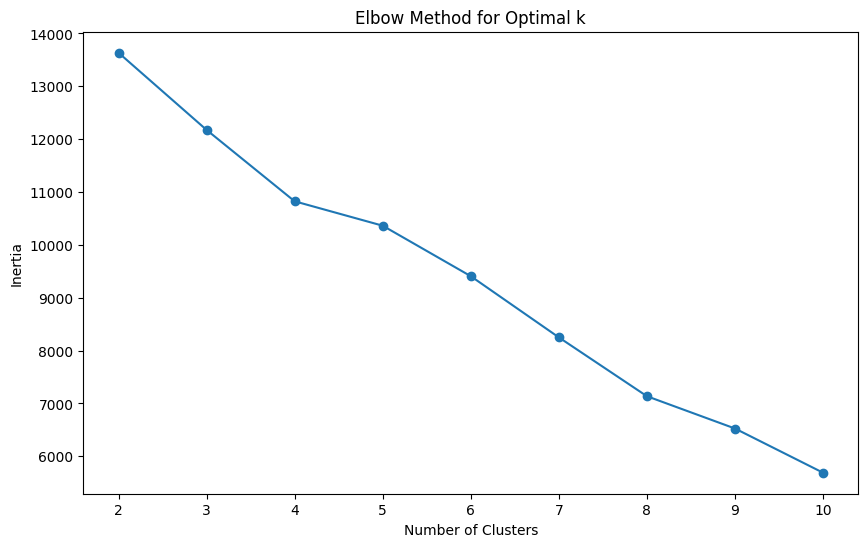

In [25]:
# Elbow plot to find out optimal number of clusters
import matplotlib.pyplot as plt


# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(cluster_sizes, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

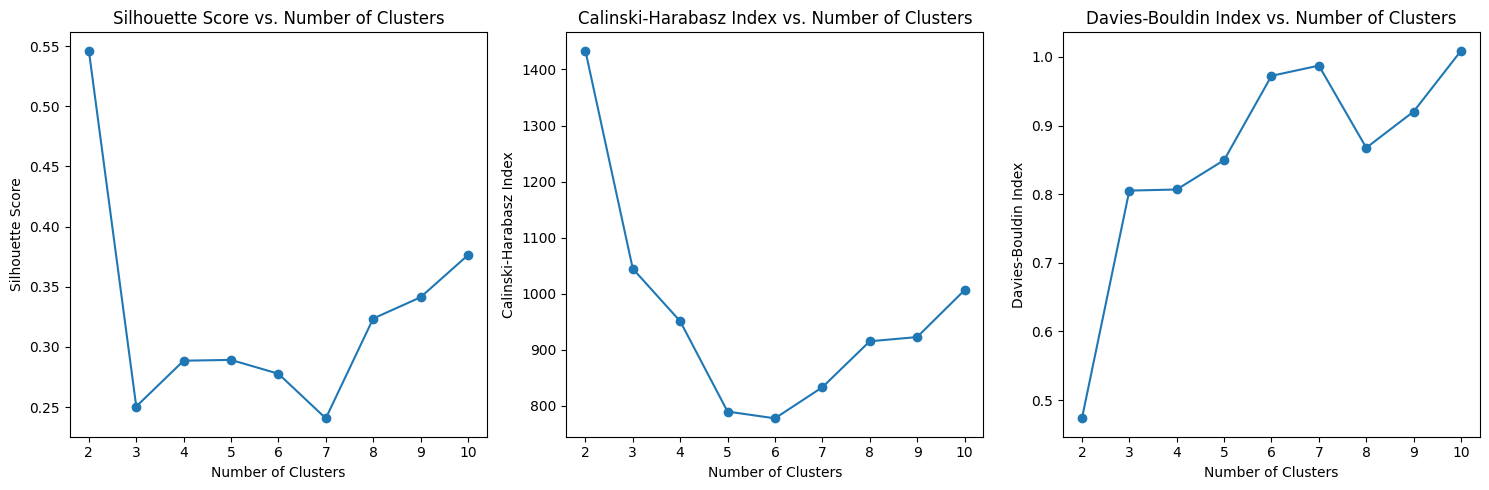

In [26]:
# Plot metrics vs number of clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))


# Plot the metrics against the number of clusters
plt.subplot(1, 3, 1)
plt.plot(cluster_sizes, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')

plt.subplot(1, 3, 2)
plt.plot(cluster_sizes, calinski_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs. Number of Clusters')

plt.subplot(1, 3, 3)
plt.plot(cluster_sizes, davies_bouldin_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs. Number of Clusters')

plt.tight_layout()
plt.show()

# Summary

Given the Balance of evidence, it looks like the optimal amount of clusters is between 2 and 4.  This is based off the fact that the Silhouette and Calinski-Harabasz Score are Optimally High at 2 clusters and the Davies-Bouldin Score Optimally Low at 2 clusters.

Furthermore, the Inertia Chart has an Elbow at around 4 clusters.  So again, the optimal cluster range is between 2 and 4 with me leaning toward 2 given the last three charts...
